##  Load SO₂ Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

so2 = pd.read_csv("../../data/validated/SO2_cityday.csv")
so2["Date"] = pd.to_datetime(so2["Date"])
so2.head()

,City,Date,SO2_daily,Year,Month
0,St. John's,2020-01-01,0.066667,2020,1
1,St. John's,2020-01-02,0.458333,2020,1
2,St. John's,2020-01-03,0.470833,2020,1
3,St. John's,2020-01-04,0.766667,2020,1
4,St. John's,2020-01-05,0.666667,2020,1


## Convert Date Column

In [18]:
so2["Date"] = pd.to_datetime(so2["Date"])

print("Date range:", so2["Date"].min(), "→", so2["Date"].max())

Date range: 2020-01-01 00:00:00 → 2023-12-31 00:00:00


## Missing Value Summary

In [20]:
print("Missing Values per Column:")
print(so2.isna().sum())

missing_percent = (so2.isna().sum() / len(so2)) * 100

print("\nMissing Percentage:")
print(missing_percent)

Missing Values per Column:
City         0
Date         0
SO2_daily    0
Year         0
Month        0
dtype: int64

Missing Percentage:
City         0.0
Date         0.0
SO2_daily    0.0
Year         0.0
Month        0.0
dtype: float64


The missing value summary confirms the dataset is largely complete, allowing reliable analysis without significant data loss.

## Summary Statistics

In [22]:
so2["SO2_daily"].describe()

count    148454.000000
mean          0.622423
std           1.727709
min          -0.079167
25%           0.100000
50%           0.241667
75%           0.533333
max          67.600000
Name: SO2_daily, dtype: float64

The descriptive statistics provide an overview of SO₂ concentration levels across all 
observations. The mean value represents the average pollution level, while the minimum 
and maximum values indicate the variability in air quality conditions.

The presence of large differences between the mean and maximum values suggests occasional 
pollution spikes, which may be related to industrial activity, traffic emissions, or 
seasonal environmental factors.

## Distribution of SO₂ Daily Concentrations

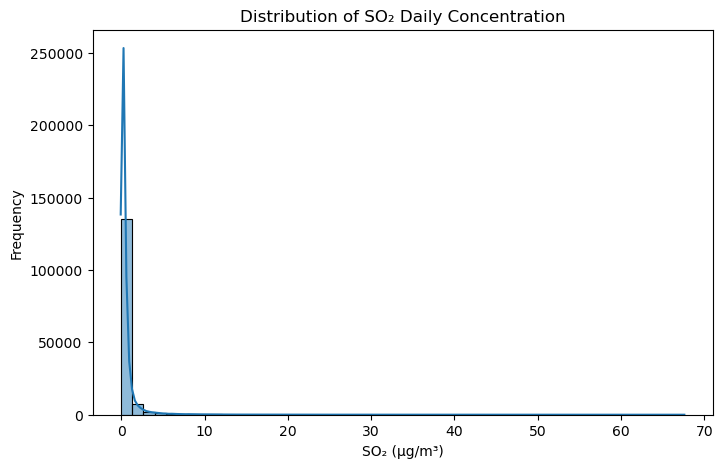

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(so2["SO2_daily"], bins=50, kde=True)

plt.title("Distribution of SO₂ Daily Concentration")
plt.xlabel("SO₂ (µg/m³)")
plt.ylabel("Frequency")

plt.show()

The SO₂ concentration distribution is right-skewed, with most observations at low levels and a few high-value pollution spikes. This indicates that extreme SO₂ events occur occasionally but are not typical of daily air quality conditions.

## Outlier Detection (Boxplot)

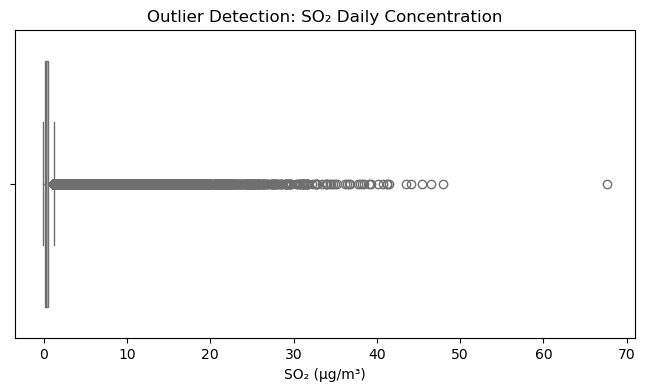

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x=so2["SO2_daily"], color="skyblue")

plt.title("Outlier Detection: SO₂ Daily Concentration")
plt.xlabel("SO₂ (µg/m³)")
plt.show()

The boxplot visualization helps identify extreme SO₂ observations. 
Outliers may represent short-term pollution events such as industrial emissions, 
weather-driven accumulation of pollutants, or measurement anomalies.

Identifying these values is important because extreme pollution levels can influence 
model performance and bias statistical summaries.

## Create Year and Month Columns

In [28]:
so2["Year"] = so2["Date"].dt.year
so2["Month"] = so2["Date"].dt.month

## Yearly Trend Analysis

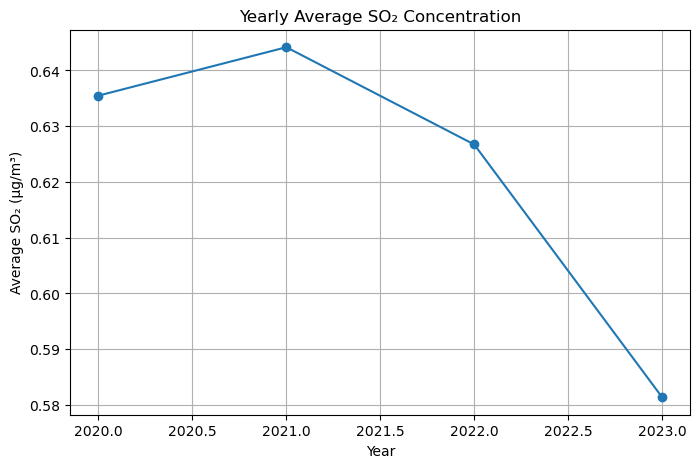

In [30]:
yearly_trend = so2.groupby("Year")["SO2_daily"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o')

plt.title("Yearly Average SO₂ Concentration")
plt.xlabel("Year")
plt.ylabel("Average SO₂ (µg/m³)")
plt.grid(True)
plt.show()

The yearly trend analysis evaluates whether SO₂ pollution levels are increasing or 
decreasing over time. Observing long-term changes helps identify the effectiveness of 
environmental regulations, emission control policies, or shifts in industrial activity.

If a downward trend is observed, it may indicate improved pollution control measures, 
while upward trends may suggest growing urban or industrial emissions.

## Seasonal Pattern (Monthly Analysis)

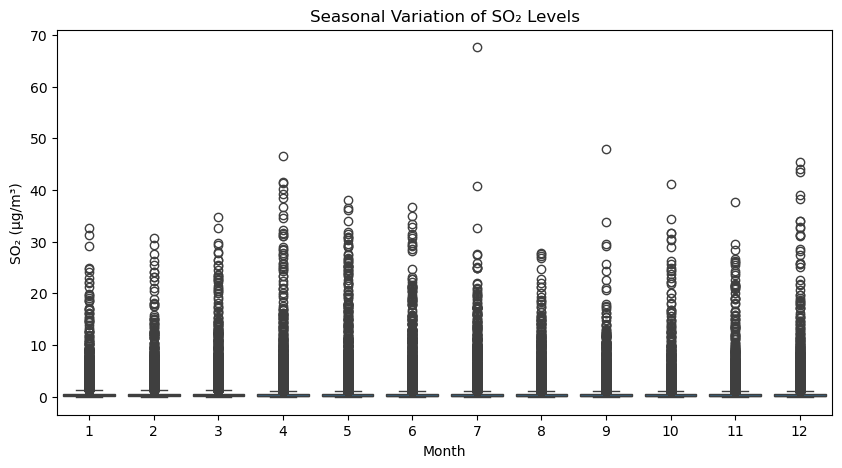

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Month", y="SO2_daily", data=so2)

plt.title("Seasonal Variation of SO₂ Levels")
plt.xlabel("Month")
plt.ylabel("SO₂ (µg/m³)")
plt.show()

The monthly analysis highlights seasonal variations in SO₂ concentrations. 
Higher levels during winter months are commonly observed in many cities due to 
increased fuel combustion for heating and reduced atmospheric dispersion.

Seasonal variability indicates that SO₂ pollution is influenced by climatic and 
human-activity patterns. This justifies the use of time-series models that incorporate 
seasonal components.

## Top Polluted Cities

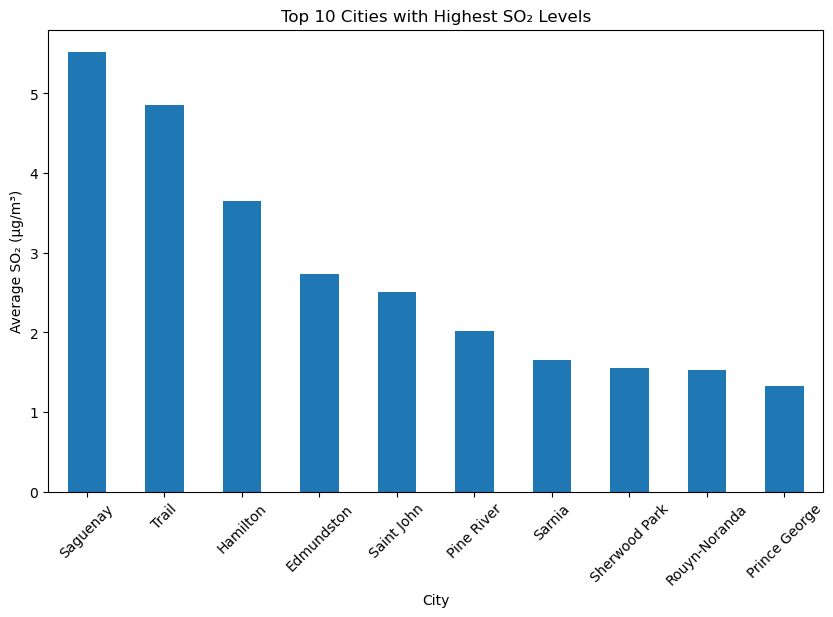

In [34]:
city_avg = so2.groupby("City")["SO2_daily"].mean().sort_values(ascending=False)

top10 = city_avg.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")

plt.title("Top 10 Cities with Highest SO₂ Levels")
plt.xlabel("City")
plt.ylabel("Average SO₂ (µg/m³)")
plt.xticks(rotation=45)
plt.show()

City-level analysis reveals geographical disparities in SO₂ pollution levels. 
Cities with consistently higher SO₂ concentrations may be associated with heavy 
industrial activity, dense traffic networks, or coal-based energy production.

Understanding city-specific pollution patterns is important for targeted environmental 
policy interventions and localized pollution control strategies.

## Prepare for Correlation with PM2.5 / NO₂

In [36]:
so2_corr = so2[["Date","City","SO2_daily"]]
so2_corr.head()

,Date,City,SO2_daily
0,2020-01-01,St. John's,0.066667
1,2020-01-02,St. John's,0.458333
2,2020-01-03,St. John's,0.470833
3,2020-01-04,St. John's,0.766667
4,2020-01-05,St. John's,0.666667


## Load PM2.5 and NO₂ Data

In [40]:
pm25 = pd.read_csv("../../data/validated/PM25_cityday.csv")
no2  = pd.read_csv("../../data/validated/NO2_cityday.csv")
so2  = pd.read_csv("../../data/validated/SO2_cityday.csv")

print("PM2.5 shape:", pm25.shape)
print("NO2 shape:", no2.shape)
print("SO2 shape:", so2.shape)

PM2.5 shape: (256216, 5)
NO2 shape: (218411, 5)
SO2 shape: (148454, 5)


## Convert Date Columns

In [42]:
pm25["Date"] = pd.to_datetime(pm25["Date"])
no2["Date"] = pd.to_datetime(no2["Date"])
so2["Date"] = pd.to_datetime(so2["Date"])

## Select Required Columns

In [44]:
pm25_df = pm25[["Date","City","PM25_daily"]]
no2_df = no2[["Date","City","NO2_daily"]]
so2_df = so2[["Date","City","SO2_daily"]]

## Merge the Datasets

In [46]:
merged = pm25_df.merge(no2_df, on=["Date","City"], how="inner")

merged = merged.merge(so2_corr, on=["Date","City"], how="inner")

print("Merged dataset shape:", merged.shape)

merged.head()

Merged dataset shape: (124732, 5)


,Date,City,PM25_daily,NO2_daily,SO2_daily
0,2020-01-01,Ottawa,4.166667,6.041667,0.104167
1,2020-01-02,Ottawa,5.708333,14.208333,0.162500
2,2020-01-03,Ottawa,8.166667,12.000000,0.187500
3,2020-01-04,Ottawa,3.708333,5.375000,0.104167
4,2020-01-05,Ottawa,3.750000,6.125000,0.062500


## Handle Missing Values After Merge

In [48]:
merged = merged.sort_values(["City","Date"])

merged = merged.groupby("City").apply(
    lambda x: x.interpolate(limit_direction="both")
).reset_index(drop=True)

C:\Users\hetac\AppData\Local\Temp\ipykernel_6208\3794179869.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(limit_direction="both")
C:\Users\hetac\AppData\Local\Temp\ipykernel_6208\3794179869.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(limit_direction="both")
C:\Users\hetac\AppData\Local\Temp\ipykernel_6208\3794179869.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(limit_direction="both")
C:\Users\hetac\AppData\Local\Temp\ipykernel_6208\3794179869.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and wil

## Correlation Matrix

In [50]:
corr_matrix = merged[["PM25_daily","NO2_daily","SO2_daily"]].corr()

corr_matrix

,PM25_daily,NO2_daily,SO2_daily
PM25_daily,1.000000,0.116803,0.046868
NO2_daily,0.116803,1.000000,0.128664
SO2_daily,0.046868,0.128664,1.000000


The correlation analysis evaluates the relationship between multiple air pollutants 
including PM2.5, NO₂, and SO₂. Positive correlations indicate that pollutants may 
share common emission sources such as vehicle traffic, industrial activities, or 
fossil fuel combustion.

Strong correlations between pollutants suggest that changes in one pollutant level 
may be associated with changes in others. These relationships are important when 
building predictive models for air quality forecasting.

## Correlation Heatmap

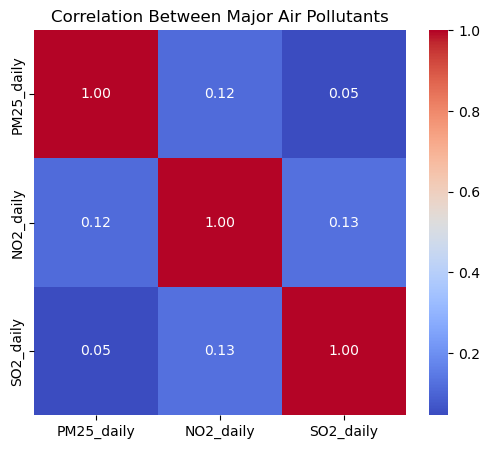

In [52]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Major Air Pollutants")

plt.show()

## City-Level Correlation 

In [54]:
city_corr = merged.groupby("City")[["PM25_daily","NO2_daily","SO2_daily"]].corr().round(2)

city_corr.head(10)

PM25_daily  NO2_daily  SO2_daily
City                                                    
Anzac       PM25_daily        1.00       0.03      -0.01
            NO2_daily         0.03       1.00       0.67
            SO2_daily        -0.01       0.67       1.00
Ardrossan   PM25_daily        1.00       0.02       0.01
            NO2_daily         0.02       1.00       0.43
            SO2_daily         0.01       0.43       1.00
Beaverlodge PM25_daily        1.00       0.12       0.10
            NO2_daily         0.12       1.00       0.59
            SO2_daily         0.10       0.59       1.00
Brossard    PM25_daily        1.00       0.56       0.16

City-level correlation analysis provides deeper insight into pollutant interactions 
within specific urban environments. Differences in correlation strength across cities 
may reflect variations in emission sources, industrial activity, and traffic density.

This localized analysis helps identify cities where pollutant interactions are 
particularly strong, which can guide more focused environmental monitoring and 
policy decisions.